# 🏨 🏬 Analyse Exploratoire de la consommation d'énergie des bâtiments non résidentiels de la ville de Seattle

### 📃 Context du document

La ville de seattle a un objectif de neutralité carbone d'ici 2050. 
En 2016, elle a effectué un relevé de tous les bâtiments de ville afin de connaitre leur consommation ainsi que leur émission de CO2. 

La ville souhaiterait actualiser ces données, mais ce genre de relevé est très couteux. 
C'est pourquoi nous souhaitons développer un modèle prédictif qui permettra de prédire la consommation d'énergie. 

La première étape consite à effectuer une analyse exploratoire pour se familiariser avec les données présentent.

### 📒 Import des modules

In [118]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [119]:
pd.options.display.float_format = '{:.2f}'.format

### 🔍 Lecture et filtrage du dataset

In [120]:
df = pd.read_csv("2016_Building_Energy_Benchmarking.csv")

##### Rapide aperçu

In [121]:
df.head()

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,...,Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.00,0659000030,...,1156514.25,3946027.00,12764.53,1276453.00,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.00,0659000220,...,950425.19,3242851.00,51450.82,5145082.00,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.00,0659000475,...,14515435.00,49526664.00,14938.00,1493800.00,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.00,0659000640,...,811525.31,2768924.00,18112.13,1811213.00,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.00,0659000970,...,1573448.62,5368607.00,88039.98,8803998.00,False,NaN,Compliant,NaN,505.01,2.88


In [122]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3376 entries, 0 to 3375
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    3376 non-null   int64  
 1   DataYear                         3376 non-null   int64  
 2   BuildingType                     3376 non-null   object 
 3   PrimaryPropertyType              3376 non-null   object 
 4   PropertyName                     3376 non-null   object 
 5   Address                          3376 non-null   object 
 6   City                             3376 non-null   object 
 7   State                            3376 non-null   object 
 8   ZipCode                          3360 non-null   float64
 9   TaxParcelIdentificationNumber    3376 non-null   object 
 10  CouncilDistrictCode              3376 non-null   int64  
 11  Neighborhood                     3376 non-null   object 
 12  Latitude            

##### Sélection des bâtiments non résidentiels

In [123]:
residential_building = ['Mixed Use Property',
                        'Residence Hall',
                        'High-Rise Multifamily',
                        'Low-Rise Multifamily',
                        'Other',
                        'Office',
                        'Mid-Rise Multifamily']

In [124]:
df = df[~df["PrimaryPropertyType"].isin(residential_building)]

In [125]:
df.shape

(1305, 46)

>⚠️ Suite à ce filtre, le dataframe a été divisé par 2.

### 🎯 Analyse de la variable cible

Compte tenu de la problèmatique (prédire la consommation d'énergie), deux variables cibles se déssinent : 
- SiteEnergyUse(kBtu)
- SiteEnergyUseWN(kBtu)

Nous choisirons ici **SiteEnergyUseWN(kBtu)** car d'après la définition, la variable a été normalisée par rapport à la météo.

*“The annual amount of energy consumed by the property from all sources of energy, adjusted to what the property would have consumed during 30-year average weather conditions.“*

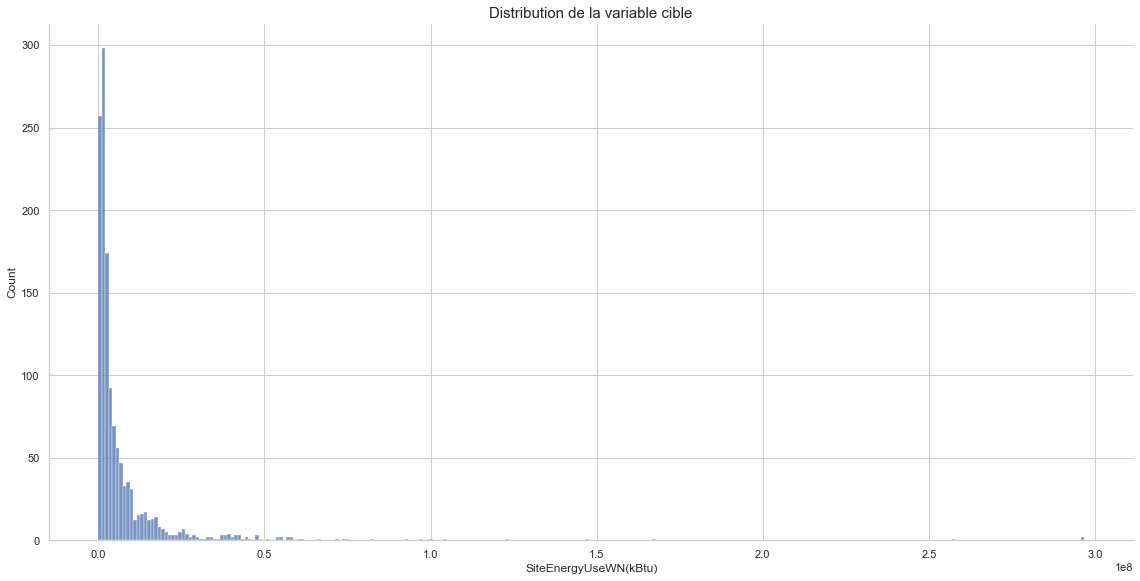

In [126]:
sns.displot(df, x="SiteEnergyUseWN(kBtu)", height=8, aspect=2)
plt.title("Distribution de la variable cible", fontsize=15)
plt.show()

>La distribution de la variable est **asymétrique**, une poignée de batiments consomments **la majorité de l'énergie**.

### 📉 Analyse univariée

In [127]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1305 entries, 0 to 3359
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    1305 non-null   int64  
 1   DataYear                         1305 non-null   int64  
 2   BuildingType                     1305 non-null   object 
 3   PrimaryPropertyType              1305 non-null   object 
 4   PropertyName                     1305 non-null   object 
 5   Address                          1305 non-null   object 
 6   City                             1305 non-null   object 
 7   State                            1305 non-null   object 
 8   ZipCode                          1305 non-null   float64
 9   TaxParcelIdentificationNumber    1305 non-null   object 
 10  CouncilDistrictCode              1305 non-null   int64  
 11  Neighborhood                     1305 non-null   object 
 12  Latitude            

##### Choix des variables quantitatives à analyser

In [128]:
quantitative_col = ['YearBuilt','Latitude','Longitude','NumberofFloors','PropertyGFAParking', 'PropertyGFATotal',
                    'NumberofBuildings','ENERGYSTARScore', 'SiteEUI(kBtu/sf)','SiteEUIWN(kBtu/sf)', 
                    'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)','SiteEnergyUse(kBtu)', 'SiteEnergyUseWN(kBtu)', 
                    'SteamUse(kBtu)','Electricity(kWh)', 'Electricity(kBtu)', 'NaturalGas(therms)',
                    'NaturalGas(kBtu)','TotalGHGEmissions', 'GHGEmissionsIntensity']

In [129]:
df.loc[:,quantitative_col].describe()

,YearBuilt,Latitude,Longitude,NumberofFloors,PropertyGFAParking,PropertyGFATotal,NumberofBuildings,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),...,SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),TotalGHGEmissions,GHGEmissionsIntensity
count,1305.00,1305.00,1305.00,1305.00,1305.00,1305.00,1304.00,1060.00,1304.00,1303.00,...,1304.00,1304.00,1303.00,1304.00,1304.00,1304.00,1304.00,1304.00,1304.00,1304.00
mean,1962.58,47.61,-122.33,4.49,12902.58,124861.22,1.16,65.72,64.38,66.47,...,159.29,8108421.97,7555314.06,583922.27,1659064.66,5660728.61,17310.01,1731000.65,176.47,1.41
std,31.89,0.05,0.03,7.17,41971.25,322798.20,3.22,28.48,61.56,62.47,...,142.63,30244615.30,18660344.22,6197944.61,6230721.78,21259222.71,61588.63,6158862.69,692.66,1.97
min,1900.00,47.50,-122.41,0.00,0.00,16300.00,0.00,1.00,0.00,0.00,...,-2.10,0.00,0.00,0.00,-33826.80,-115417.00,0.00,0.00,-0.80,-0.02
25%,1937.00,47.58,-122.34,1.00,0.00,31357.00,1.00,49.00,31.87,33.95,...,75.45,1210613.84,1265929.25,0.00,211257.35,720810.25,0.00,0.00,19.36,0.33
50%,1966.00,47.61,-122.33,3.00,0.00,52110.00,1.00,73.00,47.95,50.90,...,125.30,2498541.38,2626698.25,0.00,478167.75,1631508.50,4734.83,473483.50,48.42,0.78
75%,1988.00,47.65,-122.32,4.00,0.00,112896.00,1.00,89.00,73.05,75.30,...,188.63,6779988.50,6997391.50,0.00,1398422.62,4771418.25,14115.76,1411576.25,131.12,1.67
max,2015.00,47.73,-122.22,99.00,512608.00,9320156.00,111.00,100.00,696.70,693.10,...,1195.10,873923712.00,296671744.00,134943456.00,192577488.00,657074389.00,1381912.38,138191238.00,12307.16,25.71


#####  Analyse de la distribution

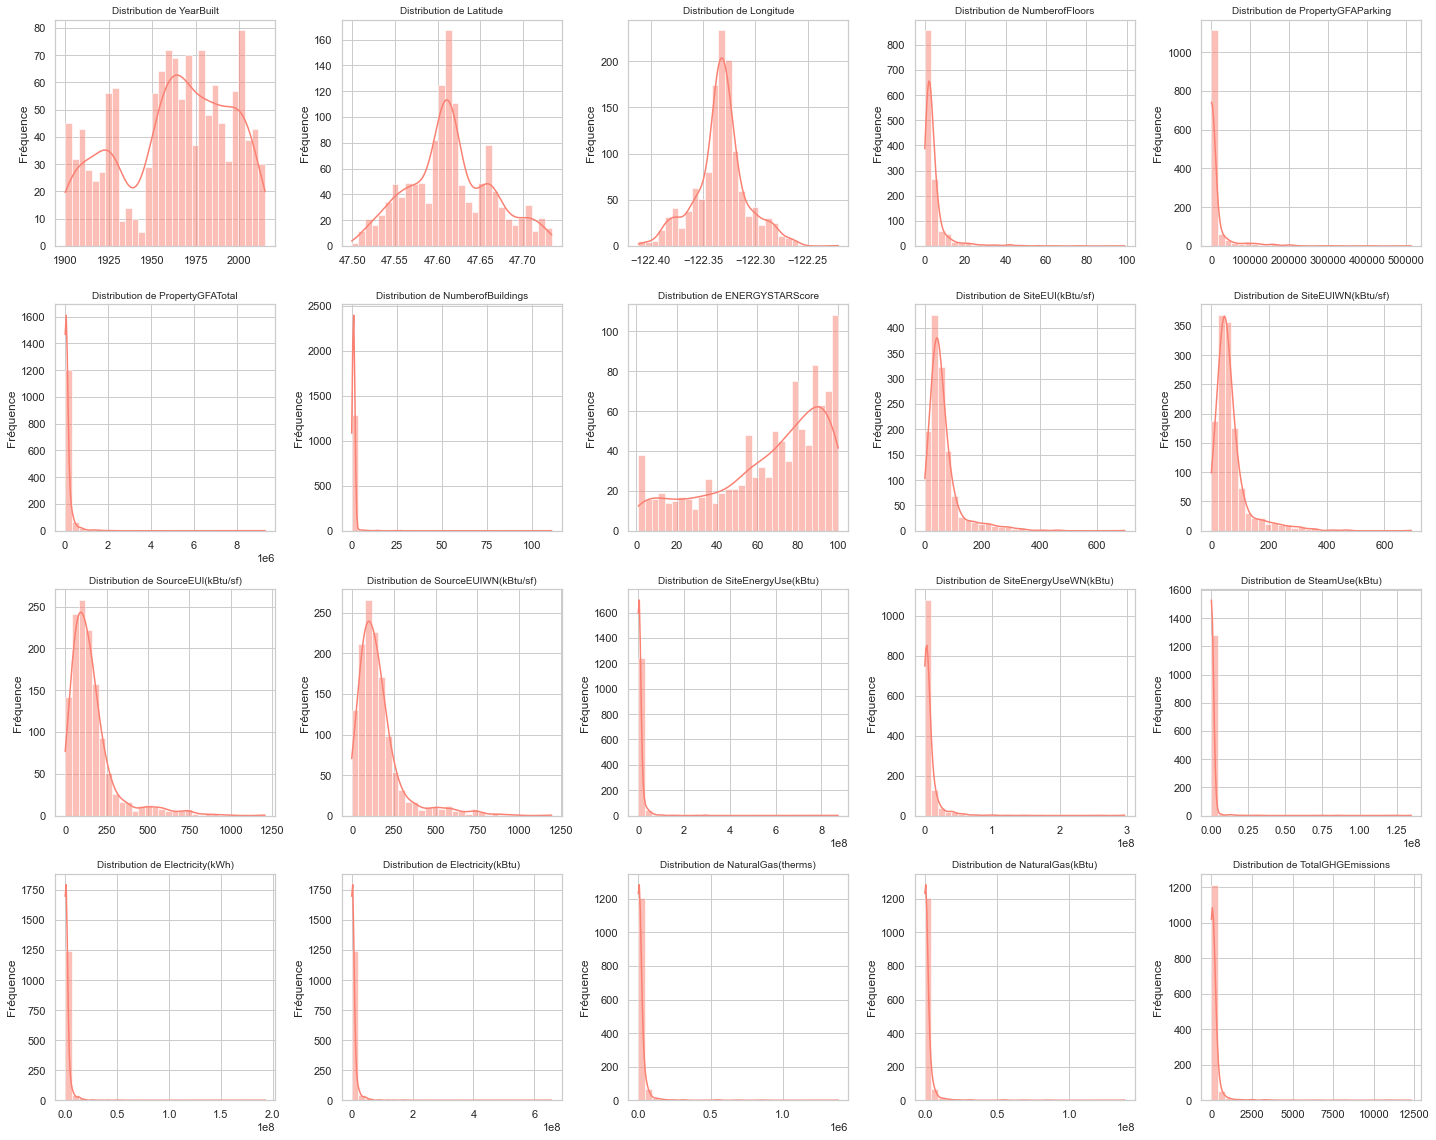

In [130]:
fig, axs = plt.subplots(4, 5, figsize=(20, 16))
axs = axs.flatten()


for i, col in enumerate(quantitative_col):
    if i < len(axs):
        sns.histplot(data=df, x=col, ax=axs[i], kde=True, color='salmon', bins=30)
        
        axs[i].set_title(f'Distribution de {col}', fontsize=10)
        axs[i].set_xlabel('')
        axs[i].set_ylabel('Fréquence')


for j in range(i + 1, len(axs)):
    axs[j].axis('off')

plt.tight_layout()
plt.show()

> Tout comme la variable cible, la plupart des variables sont également asymétriques. **Il n'y a qu'une poignée d'immense bâtiments qui consomment la majorité d'énergie.**

##### Analyse de la dispersion

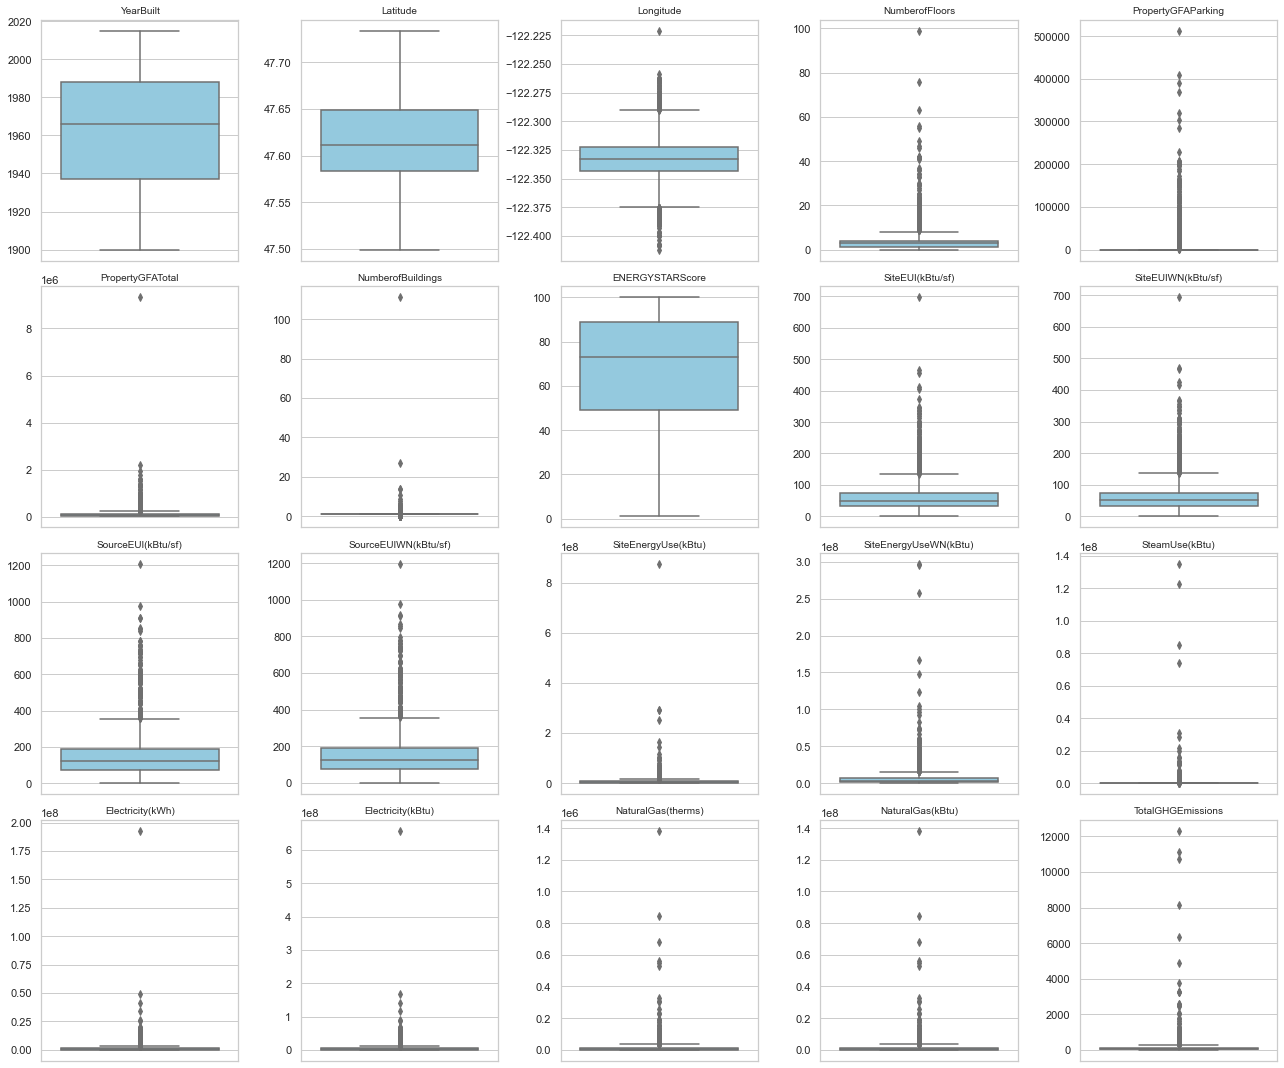

In [131]:
fig, axs = plt.subplots(4, 5, figsize=(18, 15))
axs = axs.flatten()

# On itère sur les colonnes quantitatives
for i, col in enumerate(quantitative_col):
    if i < len(axs):
        # Seaborn gère les NaN automatiquement
        sns.boxplot(data=df, y=col, ax=axs[i], color='skyblue')
        
        axs[i].set_title(col, fontsize=10)
        axs[i].set_ylabel('') # Nettoie l'axe Y pour plus de clarté
        axs[i].set_xlabel('')

# Masquer les axes vides
for j in range(i + 1, len(axs)):
    axs[j].axis('off')

plt.tight_layout()
plt.show()

> La dispersion des variables renvoit à la même conclusion que l'analyse de la distribution. **Les immenses bâtiments sont des valeurs extrêmes**, tant dans **leur taille** que dans **leur consommation d'énergie**.

### 📈📉 Analyse bivariée

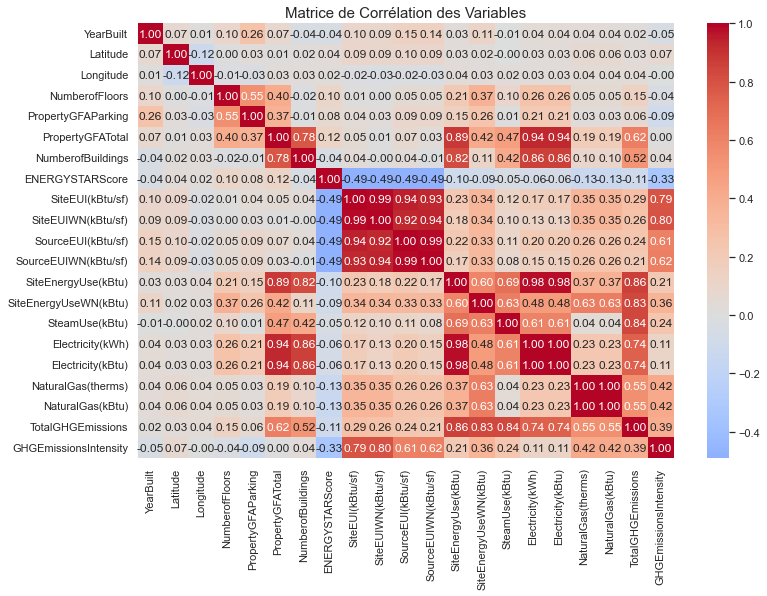

In [132]:
corr = df[quantitative_col].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(corr, 
            annot=True,       
            fmt=".2f",        
            cmap='coolwarm',  
            center=0)         

plt.title('Matrice de Corrélation des Variables', fontsize=15)
plt.show()

### 📊 Analyse catégorielle

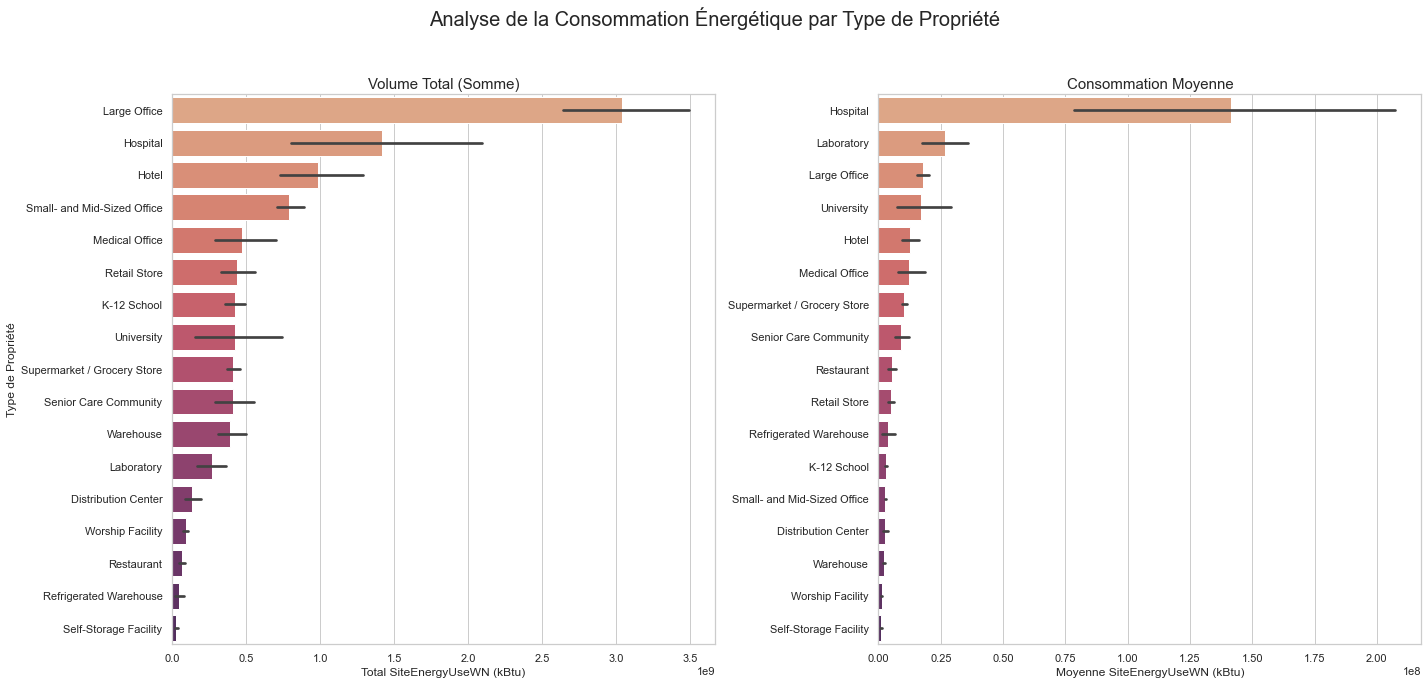

In [133]:
# Configuration du style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(20, 10))
fig.suptitle('Analyse de la Consommation Énergétique par Type de Propriété', fontsize=20)

# --- PLOT 1 : VOLUME TOTAL (SOMME) ---
order_sum = df.groupby("PrimaryPropertyType")["SiteEnergyUseWN(kBtu)"].sum().sort_values(ascending=False).index

sns.barplot(
    ax=axes[0], 
    data=df, 
    x="SiteEnergyUseWN(kBtu)", 
    y="PrimaryPropertyType",
    estimator=np.sum,      # On utilise la fonction numpy.sum
    order=order_sum, 
    palette="flare",         # Optionnel : enlève les barres d'erreur pour plus de clarté
)
axes[0].set_title("Volume Total (Somme)", fontsize=15)
axes[0].set_xlabel("Total SiteEnergyUseWN (kBtu)")
axes[0].set_ylabel("Type de Propriété")

# --- PLOT 2 : MOYENNE ---
order_mean = df.groupby("PrimaryPropertyType")["SiteEnergyUseWN(kBtu)"].mean().sort_values(ascending=False).index

sns.barplot(
    ax=axes[1], 
    data=df, 
    x="SiteEnergyUseWN(kBtu)", 
    y="PrimaryPropertyType",
    estimator=np.mean,     
    order=order_mean, 
    palette="flare",
)
axes[1].set_title("Consommation Moyenne", fontsize=15)
axes[1].set_xlabel("Moyenne SiteEnergyUseWN (kBtu)")
axes[1].set_ylabel("")


plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

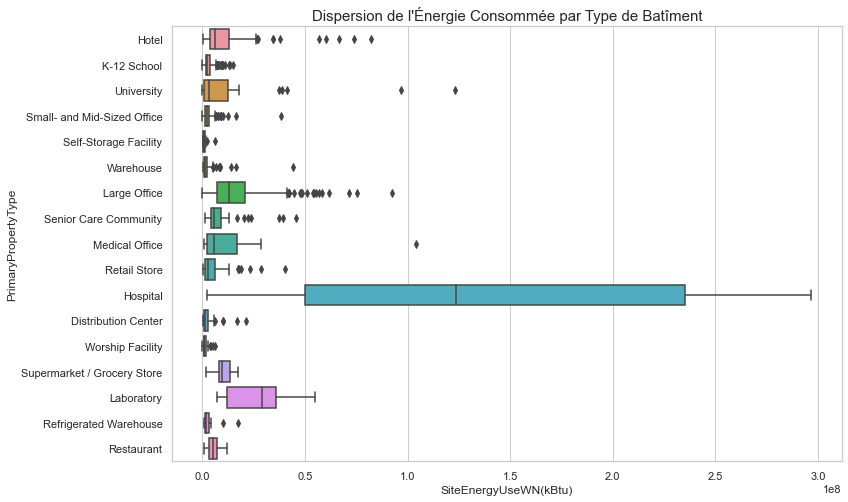

In [134]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 8))
sns.boxplot(data=df, x="SiteEnergyUseWN(kBtu)", y="PrimaryPropertyType")

plt.title("Dispersion de l'Énergie Consommée par Type de Batîment", fontsize=15)
plt.show()